<div style="float: right;">
  <a href="../de/sampling_bias.html" style="margin-left: 10px;">Deutsch</a>
  <a href="../en/sampling_bias.html">English</a>
</div>

# 2. Sampling Bias

### What is Sampling Bias?

Imagine you want to study reading habits across an entire city, so you hand out
surveys at the public library. Almost everyone you meet reads regularly, your
data looks great! But when you use those results to predict reading habits
*citywide*, your model will be overconfident, because you only asked people who
were already at the library. People who never go to libraries were invisible in
your data.

This is **sampling bias**: when the data used to train a model does not
accurately represent the real-world population the model will later be applied to.
Some groups appear *more often* than they should (overrepresented), while others
barely show up (underrepresented). The model learns the patterns of the majority
group well, but it struggles when it encounters the groups it rarely saw during
training.

In this tutorial, we try to **predict a worker's exact hourly wage** from their
education, work experience, weekly hours, and tenure. We train one model on a
representative sample of all age groups, and a second on data that contains
**only young workers**. Because experience is the main driver of wages and
young workers have little of it, the biased model never learns what high-experience
workers look like. When it encounters them at test time, it severely
under-predicts their wages.

In [1]:
# Install packages when running in JupyterLite (Pyodide) via Thebe.
try:
    import micropip
    await micropip.install(['scikit-learn', 'matplotlib', 'pandas', 'numpy'])
except ImportError:
    pass

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import json as _json, io, base64
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

def rmse(y_true, y_pred):
    """Root mean squared error (lower is better)."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ── Synthetic wage population ──────────────────────────────────────────────
n = 5000
age            = np.random.normal(41, 17, n).clip(16, 67).round().astype(int)
education      = np.random.normal(14, 2.5, n).clip(8, 20).round().astype(int)
experience     = np.maximum(0, np.maximum(0, age - education - 6) +
                            np.random.normal(0, 9.5, n).clip(-15, 15))
hours_per_week = np.random.normal(40, 8, n).clip(20, 60)
tenure         = np.minimum(experience, np.random.exponential(5, n).clip(0, 25))

wage = (
    5.0
    + 0.10 * age        # experience is the main driver
    + 0.20 * tenure
    + 0.15 * education
    + 0.1 * hours_per_week
    + np.random.normal(0, 3, n)
).clip(10, None)

df = pd.DataFrame({
    'age':            age,
    'education':      education,
    'experience':     experience,
    'hours_per_week': hours_per_week,
    'tenure':         tenure,
    'wage':           wage,
})

def age_group(a):
    if a < 30:  return 'Under 30'
    if a <= 54: return '30–54'
    return '55 and older'

df['age_group'] = df['age'].apply(age_group)
GROUP_ORDER  = ['Under 30', '30–54', '55 and older']
GROUP_COLORS = {'Under 30': 'mediumpurple', '30–54': 'steelblue', '55 and older': 'darkorange'}

# Age is NOT used as a feature. The model only sees education, experience,
# hours per week, and tenure. It must learn wage patterns from those alone.
feature_cols = ['education', 'hours_per_week', 'experience', 'tenure']

# Fixed balanced test set: stays constant across all experiments
df_full_train, df_test = train_test_split(df, test_size=0.3, random_state=42)
df_test = df_test.copy()

KEEP_FRACTION = 0.0   # keep 0% of middle-aged and older workers (young workers only)

def make_biased_sample(df_tr, keep_fraction):
    """
    Keep ALL young workers (under 30) but only a random fraction of
    middle-aged and older workers.
    keep_fraction=1.0 means no bias; 0.0 means young workers only.
    """
    young  = df_tr[df_tr['age'] < 30]
    middle = df_tr[(df_tr['age'] >= 30) & (df_tr['age'] <= 54)].sample(frac=keep_fraction, random_state=42)
    older  = df_tr[df_tr['age'] > 54].sample(frac=keep_fraction, random_state=42)
    return pd.concat([young, middle, older]).reset_index(drop=True)

---

## The True Population

Before introducing any bias, let's look at the wage distribution across age groups.
Experience accumulates with age, and since experience is the main driver of wages
in our model, older workers earn substantially more on average.

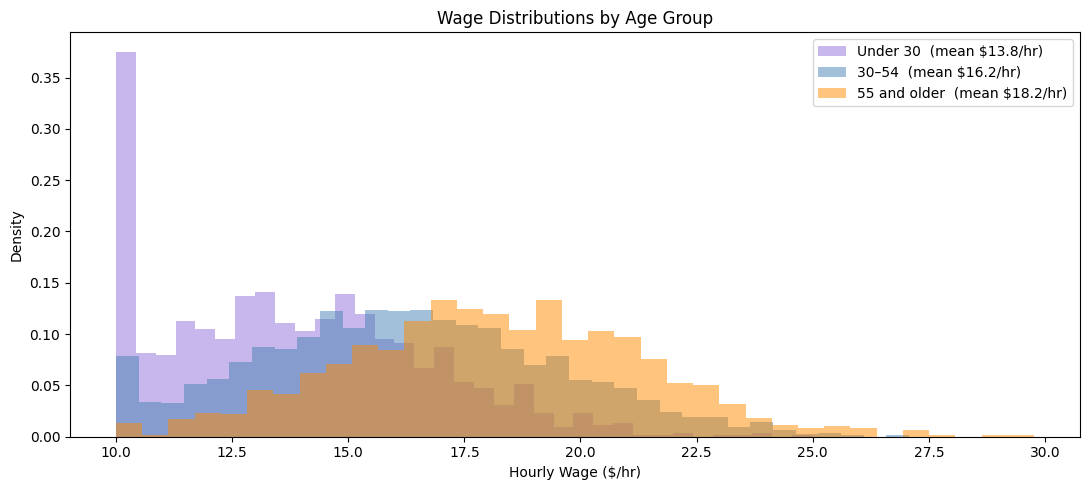

Mean wages in the full population:
  Under 30          : $13.8/hr  (n=1226)
  30–54             : $16.2/hr  (n=2721)
  55 and older      : $18.2/hr  (n=1053)


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

for group in GROUP_ORDER:
    wages = df.loc[df['age_group'] == group, 'wage']
    ax.hist(wages, bins=35, alpha=0.5, color=GROUP_COLORS[group],
             label=f'{group}  (mean ${wages.mean():.1f}/hr)', density=True)

ax.set_xlabel('Hourly Wage ($/hr)')
ax.set_ylabel('Density')
ax.set_title('Wage Distributions by Age Group')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Mean wages in the full population:")
for g in GROUP_ORDER:
    subset = df[df['age_group'] == g]
    print(f"  {g:<18}: ${subset['wage'].mean():.1f}/hr  (n={len(subset)})")

The three distributions are clearly separated: young workers cluster around \$14/hr,
middle-aged workers around \$16/hr, and older workers above \$18/hr. A model that
has only seen young workers will have no idea that wages can reach these levels.

## Creating a Biased Sample

We now create a biased training set by keeping **all** young workers but
**none** of the middle-aged and older workers. This simulates a data collection
scenario such as an online survey that only reached early-career professionals.

In [4]:
df_biased_train = make_biased_sample(df_full_train, keep_fraction=KEEP_FRACTION)

print("Training set composition before and after sampling bias")
print("=" * 60)
print(f"{'Age group':<18} {'Original':>10} {'Biased':>8}  {'% kept':>8}")
print("-" * 60)
for g in GROUP_ORDER:
    orig = (df_full_train['age_group'] == g).sum()
    bias = (df_biased_train['age_group'] == g).sum()
    pct  = 100 * bias / orig if orig > 0 else 0
    print(f"{g:<18} {orig:>10} {bias:>8}  {pct:>7.0f}%")

print(f"\nMean wage in balanced training: ${df_full_train['wage'].mean():.1f}/hr")
print(f"Mean wage in biased training:   ${df_biased_train['wage'].mean():.1f}/hr")

Training set composition before and after sampling bias
Age group            Original   Biased    % kept
------------------------------------------------------------
Under 30                  868      868      100%
30–54                    1884        0        0%
55 and older              748        0        0%

Mean wage in balanced training: $16.0/hr
Mean wage in biased training:   $13.8/hr


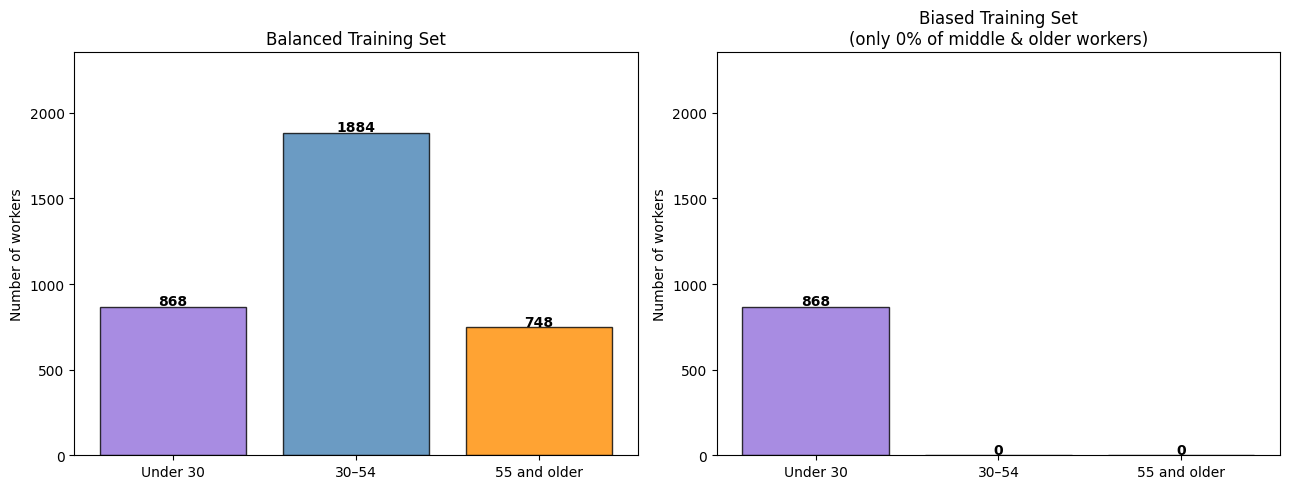

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df_plot, title in [
    (axes[0], df_full_train,   'Balanced Training Set'),
    (axes[1], df_biased_train, f'Biased Training Set\n(only {int(KEEP_FRACTION*100)}% of middle & older workers)'),
]:
    counts = {g: (df_plot['age_group'] == g).sum() for g in GROUP_ORDER}
    vals   = [counts[g] for g in GROUP_ORDER]
    colors = [GROUP_COLORS[g] for g in GROUP_ORDER]
    ax.bar(GROUP_ORDER, vals, color=colors, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Number of workers')
    ax.set_title(title)
    ax.set_ylim(0, max((df_full_train['age_group'] == g).sum() for g in GROUP_ORDER) * 1.25)
    for i, v in enumerate(vals):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The biased set contains only young workers. Its mean wage is around \$12/hr.
The model trained on this data will never learn that wages can reach \$20–30/hr.

## Training Two Models

We use a **decision tree regressor**: a model that learns if-then rules to
predict a numerical outcome. For example: *"Does this worker have more than
15 years of experience? If yes, predict a higher wage."* Each rule is learned
purely from the training examples the model has seen. Crucially, a decision tree
does **not** guess beyond its training range: if it has only ever seen workers
earning \$10–20/hr, it has no basis for predicting \$25/hr for anyone.
Other models might be more flexible and able to extrapolate the wages using factors
like work experience, but they would still struggle to learn the correct patterns
just from young workers alone.

- **Balanced model**: trained on the full, representative training set
- **Biased model**: trained only on young workers (no middle-aged or older workers)

Both models are then tested on the *same* test set, which reflects the true age
distribution of the population.

In [6]:
# Balanced model. Sees all age groups in their true proportions
tree_balanced = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_balanced.fit(df_full_train[feature_cols], df_full_train['wage'])

# Biased model trained on young workers only
tree_biased = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_biased.fit(df_biased_train[feature_cols], df_biased_train['wage'])

# Store predictions as new columns in the test table
df_test['pred_balanced'] = tree_balanced.predict(df_test[feature_cols])
df_test['pred_biased']   = tree_biased.predict(df_test[feature_cols])

# Overall RMSE: average prediction error (lower is better)
print(f"Overall prediction error RMSE (lower is better):")
print(f"  Balanced model: {rmse(df_test['wage'], df_test['pred_balanced']):.2f} $/hr")
print(f"  Biased model:   {rmse(df_test['wage'], df_test['pred_biased']):.2f} $/hr")
print()
print(f"Mean predicted wage vs actual:")
print(f"  Actual:         ${df_test['wage'].mean():.1f}/hr")
print(f"  Balanced model: ${df_test['pred_balanced'].mean():.1f}/hr")
print(f"  Biased model:   ${df_test['pred_biased'].mean():.1f}/hr  <-- underestimates the wages")

Overall prediction error RMSE (lower is better):
  Balanced model: 3.11 $/hr
  Biased model:   3.71 $/hr

Mean predicted wage vs actual:
  Actual:         $16.1/hr
  Balanced model: $16.0/hr
  Biased model:   $14.5/hr  <-- underestimates the wages


The biased model's overall error is much larger. But the overall number hides
*who* the model is getting wrong.

## How Each Group Is Predicted

For each age group we compare the **actual mean wage**, the **balanced model's**
prediction, and the **biased model's** prediction.

In [7]:
print(f"{'Age group':<18} {'Actual':>10} {'Balanced':>10} {'Biased':>8}  {'Biased RMSE':>12}")
print("-" * 62)
for g in GROUP_ORDER:
    subset = df_test[df_test['age_group'] == g]
    actual   = subset['wage'].mean()
    balanced = subset['pred_balanced'].mean()
    biased   = subset['pred_biased'].mean()
    err      = rmse(subset['wage'], subset['pred_biased'])
    print(f"{g:<18} ${actual:>8.1f} ${balanced:>8.1f} ${biased:>6.1f}  {err:>11.2f} $/hr")

Age group              Actual   Balanced   Biased   Biased RMSE
--------------------------------------------------------------
Under 30           $    14.0 $    14.4 $  13.8         2.87 $/hr
30–54              $    16.3 $    16.2 $  14.6         3.62 $/hr
55 and older       $    18.2 $    17.4 $  14.8         4.68 $/hr


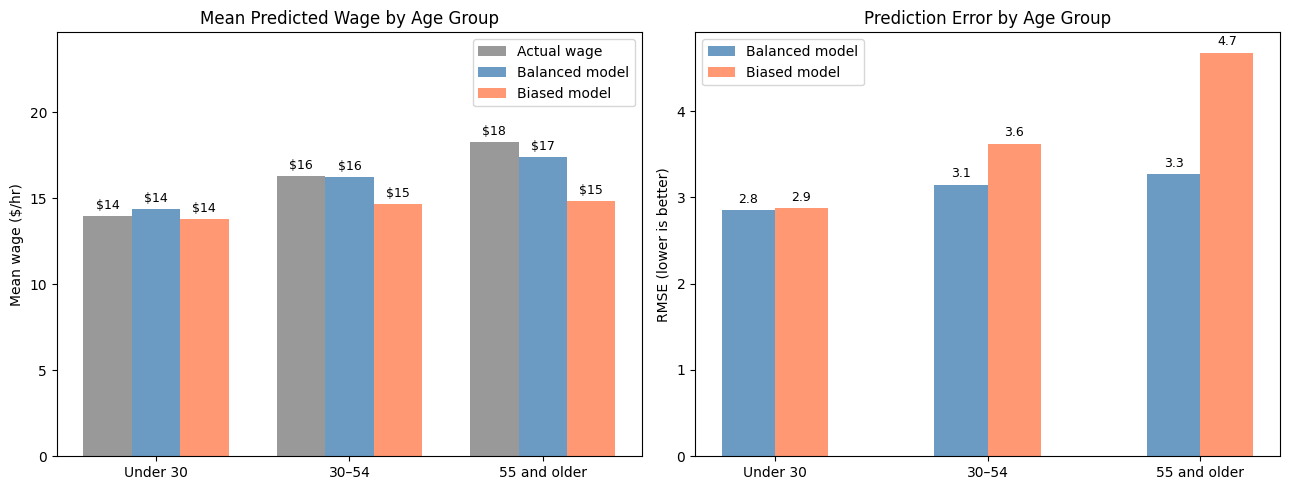

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x     = np.arange(len(GROUP_ORDER))
width = 0.25

actual_means   = [df_test[df_test['age_group'] == g]['wage'].mean()          for g in GROUP_ORDER]
balanced_means = [df_test[df_test['age_group'] == g]['pred_balanced'].mean() for g in GROUP_ORDER]
biased_means   = [df_test[df_test['age_group'] == g]['pred_biased'].mean()   for g in GROUP_ORDER]

# ── Left: mean predicted wage vs actual ──────────────────────────────────────
ba = axes[0].bar(x - width, actual_means,   width, label='Actual wage',    color='gray',      alpha=0.8)
bb = axes[0].bar(x,          balanced_means, width, label='Balanced model', color='steelblue', alpha=0.8)
bc = axes[0].bar(x + width,  biased_means,   width, label='Biased model',   color='coral',     alpha=0.8)
axes[0].set_ylabel('Mean wage ($/hr)')
axes[0].set_title('Mean Predicted Wage by Age Group')
axes[0].set_xticks(x)
axes[0].set_xticklabels(GROUP_ORDER)
axes[0].legend()
axes[0].set_ylim(0, max(actual_means) * 1.35)
for bar_group in [ba, bb, bc]:
    for bar in bar_group:
        h = bar.get_height()
        axes[0].annotate(f'${h:.0f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', va='bottom', fontsize=9)

# ── Right: RMSE by group ──────────────────────────────────────────────────────
rmse_bal = [rmse(df_test[df_test['age_group'] == g]['wage'],
                 df_test[df_test['age_group'] == g]['pred_balanced']) for g in GROUP_ORDER]
rmse_bia = [rmse(df_test[df_test['age_group'] == g]['wage'],
                 df_test[df_test['age_group'] == g]['pred_biased'])   for g in GROUP_ORDER]

rb = axes[1].bar(x - width/2, rmse_bal, width, label='Balanced model', color='steelblue', alpha=0.8)
rc = axes[1].bar(x + width/2, rmse_bia, width, label='Biased model',   color='coral',     alpha=0.8)
axes[1].set_ylabel('RMSE (lower is better)')
axes[1].set_title('Prediction Error by Age Group')
axes[1].set_xticks(x)
axes[1].set_xticklabels(GROUP_ORDER)
axes[1].legend()
for bar_group in [rb, rc]:
    for bar in bar_group:
        h = bar.get_height()
        axes[1].annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

The balanced model (blue) closely tracks actual wages for all three groups. The
biased model (coral) is stuck near the young-worker wage level for *everyone*:
it has never encountered high-experience workers and therefore has no way to
predict that their wages can be $20–30/hr. The older the group, the larger the
error.

## Interactive Explorer

How much does the degree of underrepresentation matter? Use the slider to control
what fraction of middle-aged and older workers are kept in the training data, then
click **Train & Evaluate** to see how the predictions change.

- **100 %**: no bias, fully representative training data
- **5 %**: severe bias, young workers dominate
- **0 %**: extreme: only young workers (model predicts young-worker wages for everyone)

In [9]:
_KEEP_VALUES = list(range(0, 105, 5))
_sb_data = {}

for _kf_pct in _KEEP_VALUES:
    _kf   = _kf_pct / 100.0
    _df_b = make_biased_sample(df_full_train, keep_fraction=_kf)
    _tree = DecisionTreeRegressor(max_depth=4, random_state=42)
    _tree.fit(_df_b[feature_cols], _df_b['wage'])

    _rows = []
    for _g in GROUP_ORDER:
        _sub = df_test[df_test['age_group'] == _g]
        _p   = _tree.predict(_sub[feature_cols])
        _rows.append({
            'group':    _g,
            'actual':   round(float(_sub['wage'].mean()), 1),
            'balanced': round(float(_sub['pred_balanced'].mean()), 1),
            'model':    round(float(_p.mean()), 1),
            'rmse_bal': round(float(rmse(_sub['wage'], _sub['pred_balanced'])), 2),
            'rmse_mod': round(float(rmse(_sub['wage'], _p)), 2),
        })

    _fig, _axes = plt.subplots(1, 2, figsize=(13, 4))
    _x = np.arange(len(GROUP_ORDER))
    _w = 0.25
    _ra = [r['actual']   for r in _rows]
    _rb = [r['balanced'] for r in _rows]
    _rm = [r['model']    for r in _rows]

    _axes[0].bar(_x - _w, _ra, _w, label='Actual',         color='gray',      alpha=0.8)
    _axes[0].bar(_x,       _rb, _w, label='Balanced model', color='steelblue', alpha=0.8)
    _axes[0].bar(_x + _w,  _rm, _w, label='This model',     color='coral',     alpha=0.8)
    _axes[0].set_ylabel('Mean wage ($/hr)')
    _axes[0].set_title(f'Mean Predicted Wage  (keep = {_kf_pct}%)')
    _axes[0].set_xticks(_x)
    _axes[0].set_xticklabels(GROUP_ORDER)
    _axes[0].legend()
    _axes[0].set_ylim(0, max(_ra) * 1.35)
    for _i, (_a, _b, _m) in enumerate(zip(_ra, _rb, _rm)):
        for _j, _v in enumerate([_a, _b, _m]):
            _axes[0].text(_i - _w + _j * _w, _v + 0.2, f'${_v:.0f}',
                          ha='center', va='bottom', fontsize=9)

    _rmse_b = [r['rmse_bal'] for r in _rows]
    _rmse_m = [r['rmse_mod'] for r in _rows]
    _axes[1].bar(_x - _w / 2, _rmse_b, _w, label='Balanced model', color='steelblue', alpha=0.8)
    _axes[1].bar(_x + _w / 2, _rmse_m, _w, label='This model',     color='coral',     alpha=0.8)
    _axes[1].set_ylabel('RMSE ($/hr)')
    _axes[1].set_title(f'Prediction Error by Age Group  (keep = {_kf_pct}%)')
    _axes[1].set_xticks(_x)
    _axes[1].set_xticklabels(GROUP_ORDER)
    _axes[1].legend()
    for _i, (_bv, _mv) in enumerate(zip(_rmse_b, _rmse_m)):
        for _j, _v in enumerate([_bv, _mv]):
            _axes[1].text(_i - _w / 2 + _j * _w, _v + 0.05, f'{_v:.1f}',
                          ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    _buf = io.BytesIO()
    plt.savefig(_buf, format='png', dpi=96, bbox_inches='tight')
    plt.close()
    _buf.seek(0)

    _sb_data[str(_kf_pct)] = {
        'n':    len(_df_b),
        'mean': round(float(_df_b['wage'].mean()), 1),
        'rows': _rows,
        'img':  base64.b64encode(_buf.read()).decode(),
    }

In [10]:
_js = _json.dumps(_sb_data)
display(HTML(f"""
<script>var _SB={_js};</script>
<div style="border:1px solid #ccc;padding:16px;border-radius:6px;margin:12px 0;">
  <label style="font-weight:bold;">Keep % of middle/older workers:&nbsp;</label>
  <strong id="sb-pct">0%</strong><br>
  <input type="range" id="sb-sl" min="0" max="100" step="5" value="0"
         style="width:420px;margin-top:6px;">
  <div id="sb-info" style="margin:8px 0;font-family:monospace;font-size:13px;"></div>
  <table style="border-collapse:collapse;font-size:13px;margin-bottom:10px;">
    <thead style="background:#f0f0f0;">
      <tr>
        <th style="padding:5px 10px;border:1px solid #ccc;text-align:left;">Age group</th>
        <th style="padding:5px 10px;border:1px solid #ccc;">Actual</th>
        <th style="padding:5px 10px;border:1px solid #ccc;">Balanced</th>
        <th style="padding:5px 10px;border:1px solid #ccc;">This model</th>
        <th style="padding:5px 10px;border:1px solid #ccc;">RMSE</th>
      </tr>
    </thead>
    <tbody id="sb-tb"></tbody>
  </table>
  <img id="sb-img" style="max-width:100%;" alt="Model comparison chart">
</div>
<script>
(function(){{
  var D=window._SB, sl=document.getElementById('sb-sl');
  function upd(v) {{
    var d=D[String(v)];
    document.getElementById('sb-pct').textContent=v+'%';
    document.getElementById('sb-info').textContent=
      'Training size: '+d.n+'   |   Mean wage in training: $'+d.mean+'/hr';
    document.getElementById('sb-tb').innerHTML=d.rows.map(function(r) {{
      var lo=r.model < r.balanced-1;
      return '<tr>'+
        '<td style="padding:4px 10px;border:1px solid #ccc;">'+r.group+'</td>'+
        '<td style="padding:4px 10px;border:1px solid #ccc;text-align:right;">$'+r.actual.toFixed(1)+'</td>'+
        '<td style="padding:4px 10px;border:1px solid #ccc;text-align:right;">$'+r.balanced.toFixed(1)+'</td>'+
        '<td style="padding:4px 10px;border:1px solid #ccc;text-align:right;font-weight:bold;color:'+(lo?'#c0392b':'inherit')+';">$'+r.model.toFixed(1)+'</td>'+
        '<td style="padding:4px 10px;border:1px solid #ccc;text-align:right;">'+r.rmse_mod.toFixed(2)+' $/hr</td>'+
        '</tr>';
    }}).join('');
    document.getElementById('sb-img').src='data:image/png;base64,'+d.img;
  }}
  sl.addEventListener('input', function() {{ upd(parseInt(this.value)); }});
  upd(0);
}})();
</script>
"""))

Age group,Actual,Balanced,This model,RMSE


## Key Observations

- **The overall error hides the problem**: the biased model looks reasonably
  accurate overall, because it is correct about the many young workers in the
  test set. Only group-level evaluation
  reveals how badly it fails for older workers.
- **The biased model is stuck at young-worker wages**: trained only on workers
  earning $10–16/hr, the model's predictions are capped near that range. When
  it encounters a 50-year-old with 25 years of experience, it predicts around
  $12–14/hr, even though the actual wage is closer to $22/hr.
- **Older workers are hit hardest**: the further an age group is from the
  training data, the larger the prediction error. The 55+ group, which earns
  the most, suffers the greatest under-prediction.
- **More young data makes it worse**: adding more young workers to the training
  set would increase the bias, not reduce it. What matters is *who* is in the
  data, not just how large the dataset is.
- **The slider shows the tipping point**: use the interactive explorer above to
  find at what keep percentage the biased model starts to behave like the
  balanced one. Notice how quickly predictions improve as even a small fraction
  of older workers is added back.